In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

# Load Dataset

In [3]:
X,y = load_digits(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=.8)
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((1437, 64), (1437,), (360, 64), (360,))

# Traning and Predicted Using Logistic Model

In [4]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

# Accuracy Score

    Accuracy = (total no. of correct prediction) / (total prediction)

- **How much accuracy score is good**

        It depends on the problem we are solving and kind of data we are working on
- **The Problem with Accuracy**
  - It can't tell the nature of error
    - True but pridicted False
    - False but pridicted True
  - **Solution**
    - Confusion Matrix
- **Why Accuracy is misleading**
  - Imbalanced dataset
    - True Values ( 999 )
    - False Value ( 1 )
  - Model predicting all true
    - **Accuracy** = 999/1000 = 99.9%

In [5]:
accuracy_score(y_true=y_test,y_pred=y_pred)

0.9666666666666667

# Confusion Matrix

    Accuracy = (Sum of diagonal elements) / (Sum total of matrix)

In [11]:
df = pd.DataFrame(data={'Predicted 1':['True Positive','False Positive'],
                        'Predicted 0':['False Negative','True Negative']},
                  index=['Actual 1','Actual 0'])
df

,Predicted 1,Predicted 0
Actual 1,True Positive,False Negative
Actual 0,False Positive,True Negative


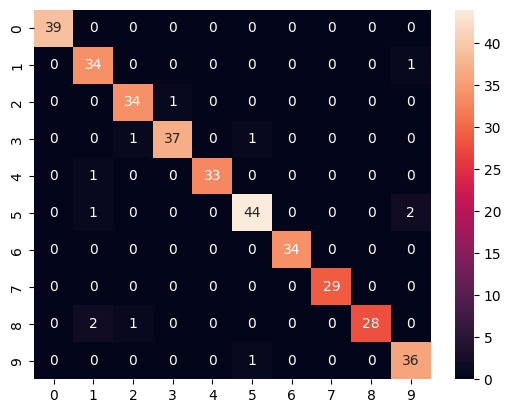

In [6]:
sns.heatmap(confusion_matrix(y_true=y_test,y_pred=y_pred),annot=True)
plt.show()

# Precicion Score

    What proportion of predicted positives is trully positive for each class
        Precision = True Posetive / (True Positive + False Posetive)

- **Average Method**
  - Macro Precicion = sigma(Precicion) / n
  - Weighted Precicion = sigma(Wi * Precicion_i) where Wi = (Actual total) / (Prected)i

In [7]:
precision_score(y_true=y_test,y_pred=y_pred,average=None)

array([1.        , 0.89473684, 0.94444444, 0.97368421, 1.        ,
       0.95652174, 1.        , 1.        , 1.        , 0.92307692])

# Recall Score

    What proportion of actual positive is correctly classifed for each class
        Recall = True Posetive / (True Posetive + False Nagetive)

- **Average Method**
  - Macro Recall = sigma(Recall) / n
  - Weighted Recall = sigma(Wi * Recall_i) where Wi = (Actual total) / (Prected)i

In [8]:
recall_score(y_true=y_test,y_pred=y_pred,average=None)

array([1.        , 0.97142857, 0.97142857, 0.94871795, 0.97058824,
       0.93617021, 1.        , 1.        , 0.90322581, 0.97297297])

# F1 Score

    Combination of Precission & Recall
        F1 Score = Harmonic Mean = (2 * Precission * Recall) / (Precission + Recall)

- **Note**
  1) Precission & Recall always have invers relationship between them, if one increase then other decrease
  2) Harmonic Mean weighted towords the lower value (Not Central Value)

- **Average Method**
  - Macro F1 Score = sigma(F1) / n
  - Weighted F1 Score = sigma(Wi * F1_i) where Wi = (Actual total) / (Prected)i

In [9]:
f1_score(y_true=y_test,y_pred=y_pred,average=None)

array([1.        , 0.93150685, 0.95774648, 0.96103896, 0.98507463,
       0.94623656, 1.        , 1.        , 0.94915254, 0.94736842])

# Classification Report

    Combines

In [10]:
print(classification_report(y_true=y_test,y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       0.89      0.97      0.93        35
           2       0.94      0.97      0.96        35
           3       0.97      0.95      0.96        39
           4       1.00      0.97      0.99        34
           5       0.96      0.94      0.95        47
           6       1.00      1.00      1.00        34
           7       1.00      1.00      1.00        29
           8       1.00      0.90      0.95        31
           9       0.92      0.97      0.95        37

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

